# Predicting Whether a Steam Game Is Free

## Summary
This notebook answers a predictive classification question: using observable Steam store metadata, can we predict whether a game is `Free` or `Paid`?

The workflow is fully reproducible. It downloads the raw dataset from the public source, stores the compressed file in `data/raw/`, writes a decompressed copy to `data/`, engineers predictors, trains a logistic regression classifier, and evaluates performance on a held-out test split.


## Introduction
Steam includes both free-to-play and paid games, and the listing metadata for each game contains signals that may be useful for prediction.

### Predictive Question
Can we predict whether a Steam game is `Free` or `Paid` from observed metadata fields (for example: category flags, platform support, release year, and age requirement)?

### Target
- Target variable: `is_free` with two classes (`Free`, `Paid`)

### Predictive framing
- This notebook is strictly predictive.
- Reported patterns are interpreted as predictive signals for classification performance, not as causal effects.


## Methods & Results
### 1) Setup

In [1]:
# ---- Setup ----
required_packages <- c(
  "jsonlite", "dplyr", "tidyr", "purrr", "lubridate", "forcats", "janitor",
  "ggplot2", "scales", "patchwork", "caret", "pROC", "knitr", "readr", "tibble"
)

missing_packages <- required_packages[
  !vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)
]

if (length(missing_packages) > 0) {
  stop(
    paste(
      "Install missing packages before running:",
      paste(missing_packages, collapse = ", ")
    )
  )
}

invisible(lapply(required_packages, library, character.only = TRUE))

project_root <- if (basename(getwd()) == "src") {
  normalizePath("..", winslash = "/")
} else {
  normalizePath(".", winslash = "/")
}

data_dir <- file.path(project_root, "data")
results_dir <- file.path(project_root, "results")
dataset_url <- "https://media.githubusercontent.com/media/VintageDon/steam-dataset-2025/main/data/01_raw/steam_2025_5k-dataset-games_20250831.json.gz"

source(file.path(project_root, "R", "io_validation_utils.R"))
source(file.path(project_root, "R", "download_data.R"))
source(file.path(project_root, "R", "extract_values.R"))
source(file.path(project_root, "R", "preprocess_data.R"))
source(file.path(project_root, "R", "plot_class_imbalance.R"))
source(file.path(project_root, "R", "plot_numeric_distributions.R"))
source(file.path(project_root, "R", "plot_target_summary.R"))
source(file.path(project_root, "R", "plot_categorical_features.R"))
source(file.path(project_root, "R", "model_training.R"))


Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union





Attaching package: 'purrr'




The following object is masked from 'package:jsonlite':

    flatten




...

Type 'citation("pROC")' for a citation.




Attaching package: 'pROC'




The following objects are masked from 'package:stats':

    cov, smooth, var





Attaching package: 'readr'




The following object is masked from 'package:scales':

    col_factor




### 2) Reproducible data download and ingestion
The code below downloads the raw compressed file from the source repository, stores it in `data/raw/`, and writes a decompressed JSON copy to `data/games_sample.json` for local analysis.


In [2]:
# ---- Reproducible data download ----
download_result <- run_data_download(
  input_url = dataset_url,
  output_data_dir = data_dir,
  fallback_urls = dataset_url
)

Dataset source: existing_local_file



Raw compressed path: C:/Users/daffa/dsci-310-group-15/data/raw/steam_2025_5k-dataset-games_20250831.json.gz



Local JSON copy: C:/Users/daffa/dsci-310-group-15/data/games_sample.json



Rows: 8711 Columns: 137



### 3) Cleaning and feature engineering

In [3]:
# ---- Cleaning and feature engineering ----
preprocess_result <- run_data_preprocessing(
  input_data_dir = data_dir,
  output_data_dir = data_dir,
  table_output_dir = data_dir,
  force = FALSE
)

df_model <- preprocess_result$modeling_table

Modeling table: 7967 rows x 30 columns



### 4) Predictor and class visual checks
The plots below are formatted to avoid severe readability problems (clear axis labels, readable text sizing, and legends where class color is used).


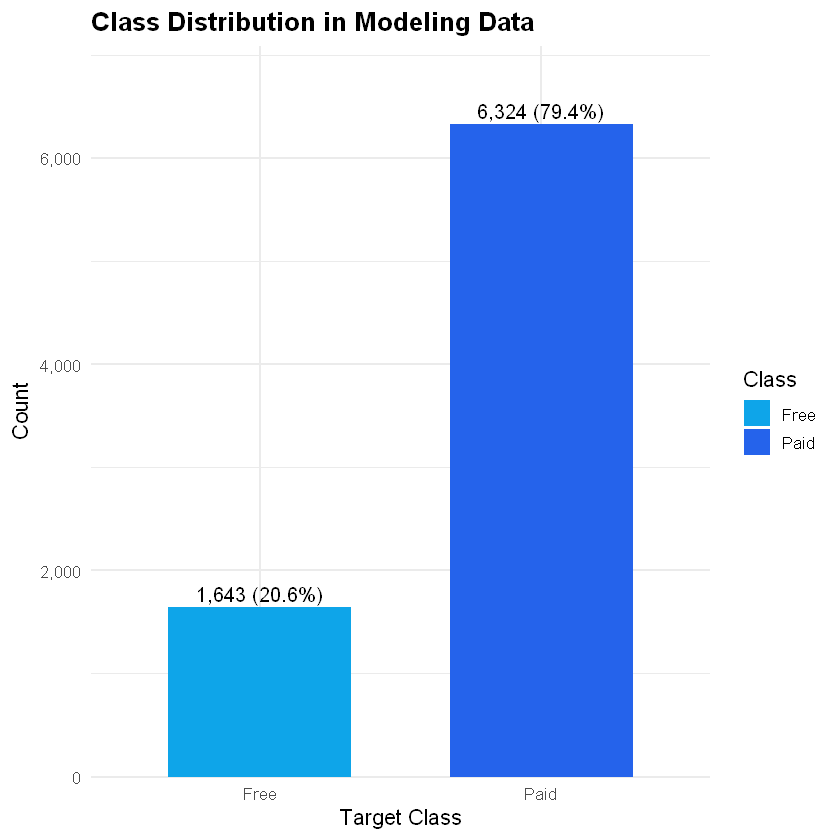

In [4]:
# ---- Class balance ----
class_result <- run_class_imbalance_check(
  input_data_dir = data_dir,
  output_object_dir = results_dir,
  output_figure_dir = results_dir
)

class_result$class_distribution_plot

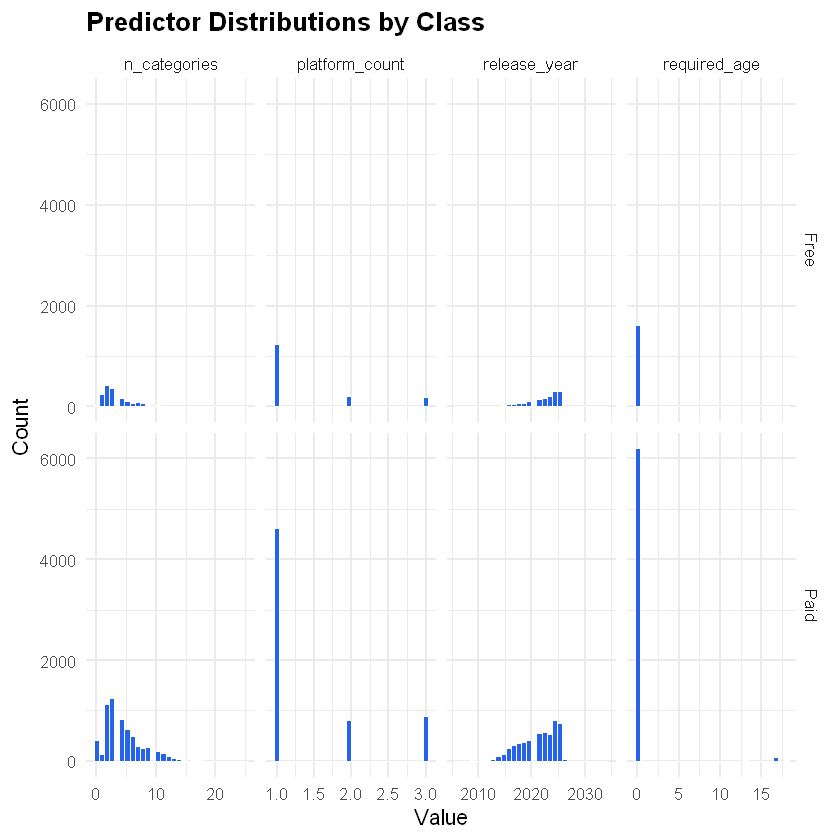

In [5]:
# ---- Numeric predictor distributions ----
numeric_result <- run_numeric_features_distributions(
  input_data_dir = data_dir,
  output_object_dir = results_dir,
  output_figure_dir = results_dir,
  target_col = "is_free",
  predictors = c("required_age", "release_year", "platform_count", "n_categories"),
  drop_non_positive_for = "release_year"
)

numeric_result$numeric_grid_distribution

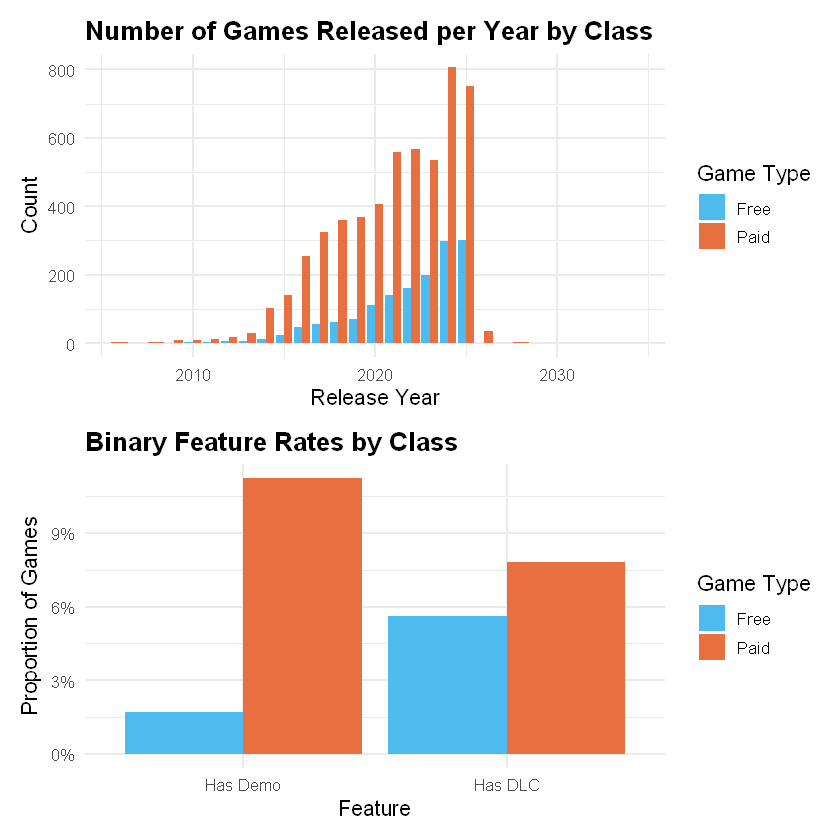

In [6]:
# ---- Additional predictor summaries ----
target_summary_result <- run_target_summary_plots(
  input_data_dir = data_dir,
  output_object_dir = results_dir,
  output_figure_dir = results_dir
)

target_summary_result$target_summary_plot

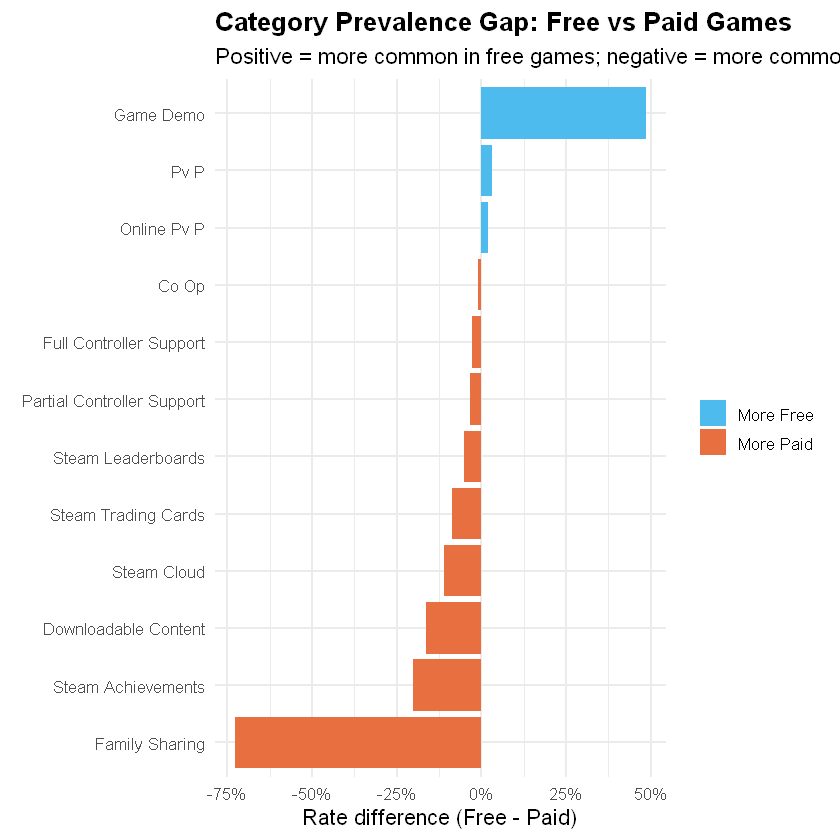

In [7]:
# ---- Category-level predictive signals ----
category_result <- run_categorical_features_plot(
  input_data_dir = data_dir,
  output_object_dir = results_dir,
  output_figure_dir = results_dir
)

category_result$category_gap_plot

### 5) Model training and held-out evaluation

In [8]:
# ---- Train/test split and logistic model ----
model_result <- run_train_test_model(
  input_data_dir = data_dir,
  results_dir = results_dir
)

knitr::kable(model_result$evaluation_metrics_table)



|metric                             |  value|
|:----------------------------------|------:|
|Baseline accuracy (majority class) | 0.7940|
|Model accuracy                     | 0.9585|
|Cohen's Kappa                      | 0.8667|
|Sensitivity (Free recall)          | 0.8323|
|Specificity (Paid recall)          | 0.9913|
|Balanced accuracy                  | 0.9118|
|ROC AUC                            | 0.9232|

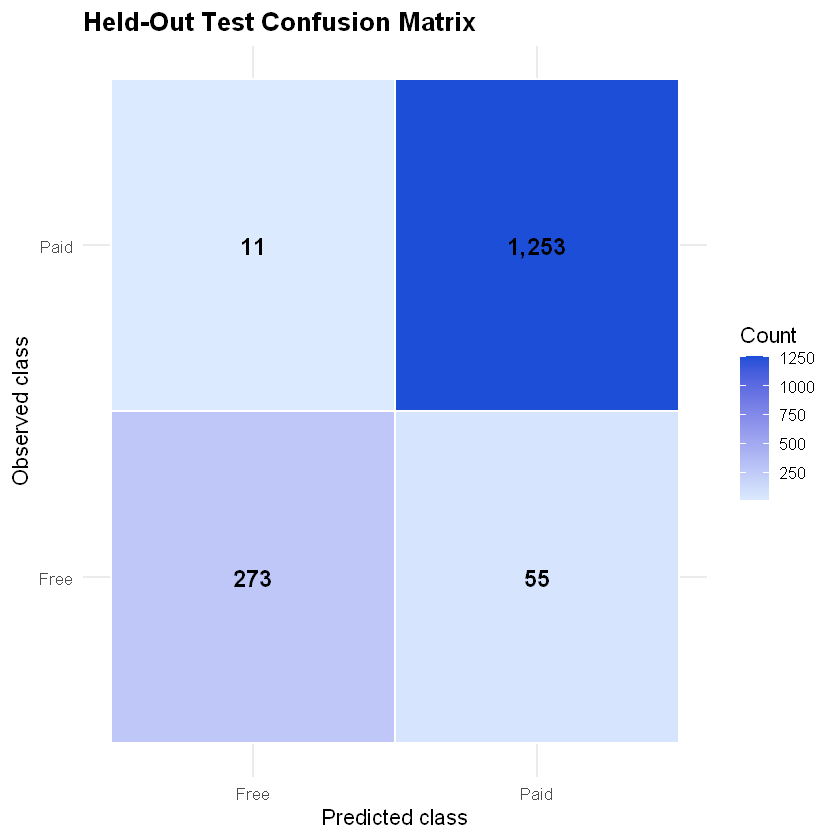

In [9]:
# ---- Confusion matrix plot ----
model_result$confusion_matrix_plot

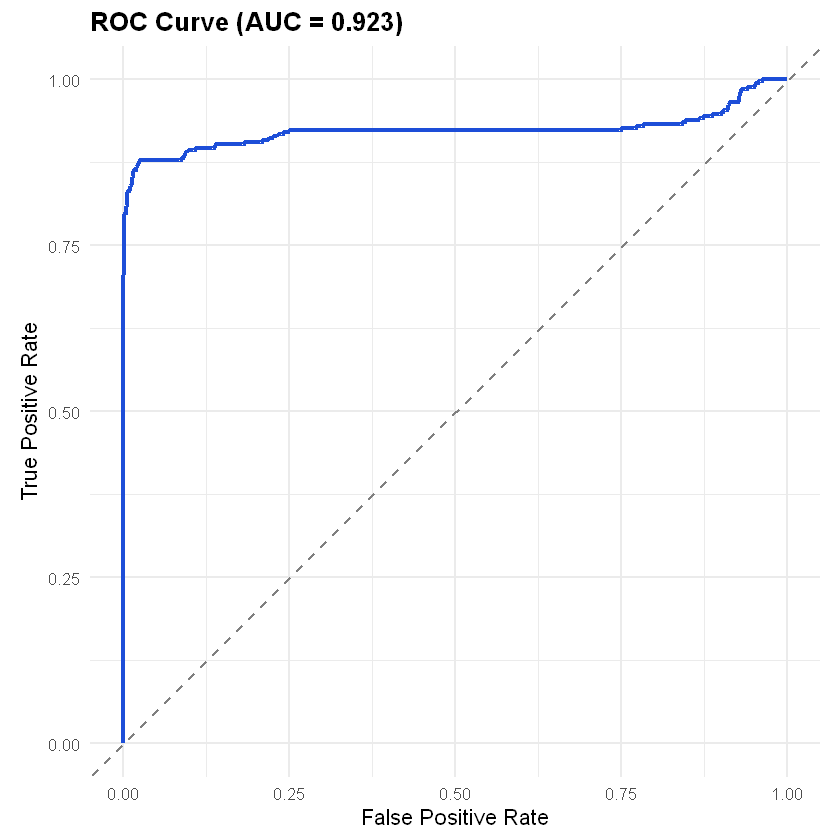

In [10]:
# ---- ROC curve ----
model_result$roc_curve_plot

In [11]:
# ---- Highest-magnitude logistic coefficients ----
knitr::kable(model_result$feature_importances)



|term                         |    Estimate|  odds_ratio| Pr(>&#124;z&#124;)|
|:----------------------------|-----------:|-----------:|------------------:|
|game_typeseries              | -39.3196049|   0.0000000|          0.9951841|
|game_typedemo                | -32.9759728|   0.0000000|          0.9943034|
|game_typemod                 | -31.9191473|   0.0000000|          0.9953210|
|windows_supportTRUE          | -16.6805443|   0.0000001|          0.9968465|
|cat_downloadable_contentTRUE | -15.7435075|   0.0000001|          0.9942093|
|game_typegame                | -14.8610852|   0.0000004|          0.9974291|
|game_typeepisode             | -14.6878564|   0.0000004|          0.9974591|
|game_typevideo               | -13.5417959|   0.0000013|          0.9976573|
|game_typemusic               | -12.5811718|   0.0000034|          0.9978235|
|cat_family_sharingTRUE       |   4.6469374| 104.2651733|          0.0000000|
|game_typedlc                 |   2.7286409|  15.3120624|     

## Discussion
This notebook answers a predictive question and reports predictive performance only.

Key takeaways from the held-out evaluation:
- The logistic model outperforms the majority-class baseline on the test split.
- The ROC AUC and balanced accuracy indicate meaningful predictive signal.
- The confusion matrix shows remaining class-specific errors, so threshold tuning may be useful for class-priority use cases.

Interpretation scope:
- Coefficients and category prevalence gaps are used here as predictive indicators.
- These results should not be interpreted as causal explanations for why games are free or paid.

Limitations for prediction:
- Class imbalance can bias decisions toward the majority class.
- The dataset is a snapshot, so predictive performance may shift over time as market patterns change.

Possible next predictive steps:
1. Compare regularized logistic regression and tree-based models on the same split.
2. Tune classification thresholds for precision-recall tradeoffs tied to the deployment goal.
3. Add probability calibration checks to improve the reliability of predicted probabilities.


## References
- Fountain, D. (2025). *Steam Dataset 2025: Multi-Modal Gaming Analytics Platform* (Version 1.0.0). Zenodo. https://doi.org/10.5281/zenodo.17286923
- VintageDon. (2025). *steam-dataset-2025* (GitHub repository). https://github.com/VintageDon/steam-dataset-2025
- Raw sample used in this notebook: https://raw.githubusercontent.com/VintageDon/steam-dataset-2025/main/data/01_raw/steam_2025_5k-dataset-games_20250831.json.gz
- Kuhn, M. (2008). Building Predictive Models in R Using the caret Package. *Journal of Statistical Software, 28*(5).
- Robin, X., et al. (2011). pROC: an open-source package for R and S+ to analyze and compare ROC curves. *BMC Bioinformatics, 12*(77).
